In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np 

In [4]:
# Caminho para o arquivo Parquet
caminho_parquet = r"C:\Users\Pichau\INMET\TODAS_ESTACOES\TODAS_ESTACOES_CONCATENADO.parquet"

# Ler o arquivo Parquet
df = pd.read_parquet(caminho_parquet)

In [5]:
# Função para calcular a maior diferença de pressão nas duas horas anteriores
def calcular_maior_diferenca(grupo):
    grupo = grupo.copy()
    
    grupo['MAIOR_DIFERENCA_TEMPERATURA_2H_ATRAS'] = (
        grupo['Temp_Amb_max'].rolling(window=2, min_periods=2).max() - 
        grupo['Temp_Amb_min'].rolling(window=2, min_periods=2).min()
    )

    grupo['MAIOR_DIFERENCA_TEMPERATURA_3H_ATRAS'] = (
        grupo['Temp_Amb_max'].rolling(window=3, min_periods=3).max() - 
        grupo['Temp_Amb_min'].rolling(window=3, min_periods=3).min()
    )
    
    return grupo

# Avaliando correlação de temperatura: FORTE DE COPACABANA.

In [7]:
# df.columns

In [8]:
COPACABANA = df[df['ESTACAO'] == 'FORTE_COPACABANA']

In [9]:
# Variáveis que quero usar. 
variaveis = ['Dt_Hr', 'ESTACAO','Precip', 'Temp_Amb_max','Temp_Amb_min',
           'VARIACAO PRIMEIRA HORA ANTERIOR TEMPERATURA AMBIENTE',
           'VARIACAO SEGUNDA HORA ANTERIOR TEMPERATURA AMBIENTE',
           'VARIACAO TERCEIRA HORA ANTERIOR TEMPERATURA AMBIENTE'
            ]

COPACABANA = COPACABANA[variaveis]

In [10]:
# Tirando esses nulos.

# Substitui os valores -9999 por NaN
COPACABANA.replace(-9999, np.nan, inplace=True)

# Conta a quantidade de valores nulos em cada coluna
missing_values = COPACABANA.isnull().sum()

# Exibe a quantidade de valores nulos
print(missing_values)

# Total de valores nulos no DataFrame
total_missing_values = COPACABANA.isnull().sum().sum()
print("Total de valores nulos no DataFrame:", total_missing_values)

Dt_Hr                                                      0
ESTACAO                                                    0
Precip                                                  5682
Temp_Amb_max                                            4751
Temp_Amb_min                                            4751
VARIACAO PRIMEIRA HORA ANTERIOR TEMPERATURA AMBIENTE    3711
VARIACAO SEGUNDA HORA ANTERIOR TEMPERATURA AMBIENTE     3712
VARIACAO TERCEIRA HORA ANTERIOR TEMPERATURA AMBIENTE    3713
dtype: int64
Total de valores nulos no DataFrame: 26320


In [11]:
COPACABANA = COPACABANA.dropna(subset=['Precip'])

In [12]:
COPACABANA = COPACABANA.reset_index(drop=True)

COPACABANA = COPACABANA.groupby('ESTACAO').apply(calcular_maior_diferenca).reset_index(drop=True)

C:\Users\Pichau\AppData\Local\Temp\ipykernel_11136\3785596157.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  COPACABANA = COPACABANA.groupby('ESTACAO').apply(calcular_maior_diferenca).reset_index(drop=True)


In [13]:
COPACABANA_CHUVA = COPACABANA[(COPACABANA['Precip'] > 0) & (COPACABANA['Precip'] < 25)]

COPACABANA_CHUVA_EXTREMA = COPACABANA[COPACABANA['Precip'] >= 25]

In [14]:
variaveis = ['Precip',
           'VARIACAO PRIMEIRA HORA ANTERIOR TEMPERATURA AMBIENTE',
           'VARIACAO SEGUNDA HORA ANTERIOR TEMPERATURA AMBIENTE',
           'VARIACAO TERCEIRA HORA ANTERIOR TEMPERATURA AMBIENTE',
            'MAIOR_DIFERENCA_TEMPERATURA_2H_ATRAS',
            'MAIOR_DIFERENCA_TEMPERATURA_3H_ATRAS'
            ]

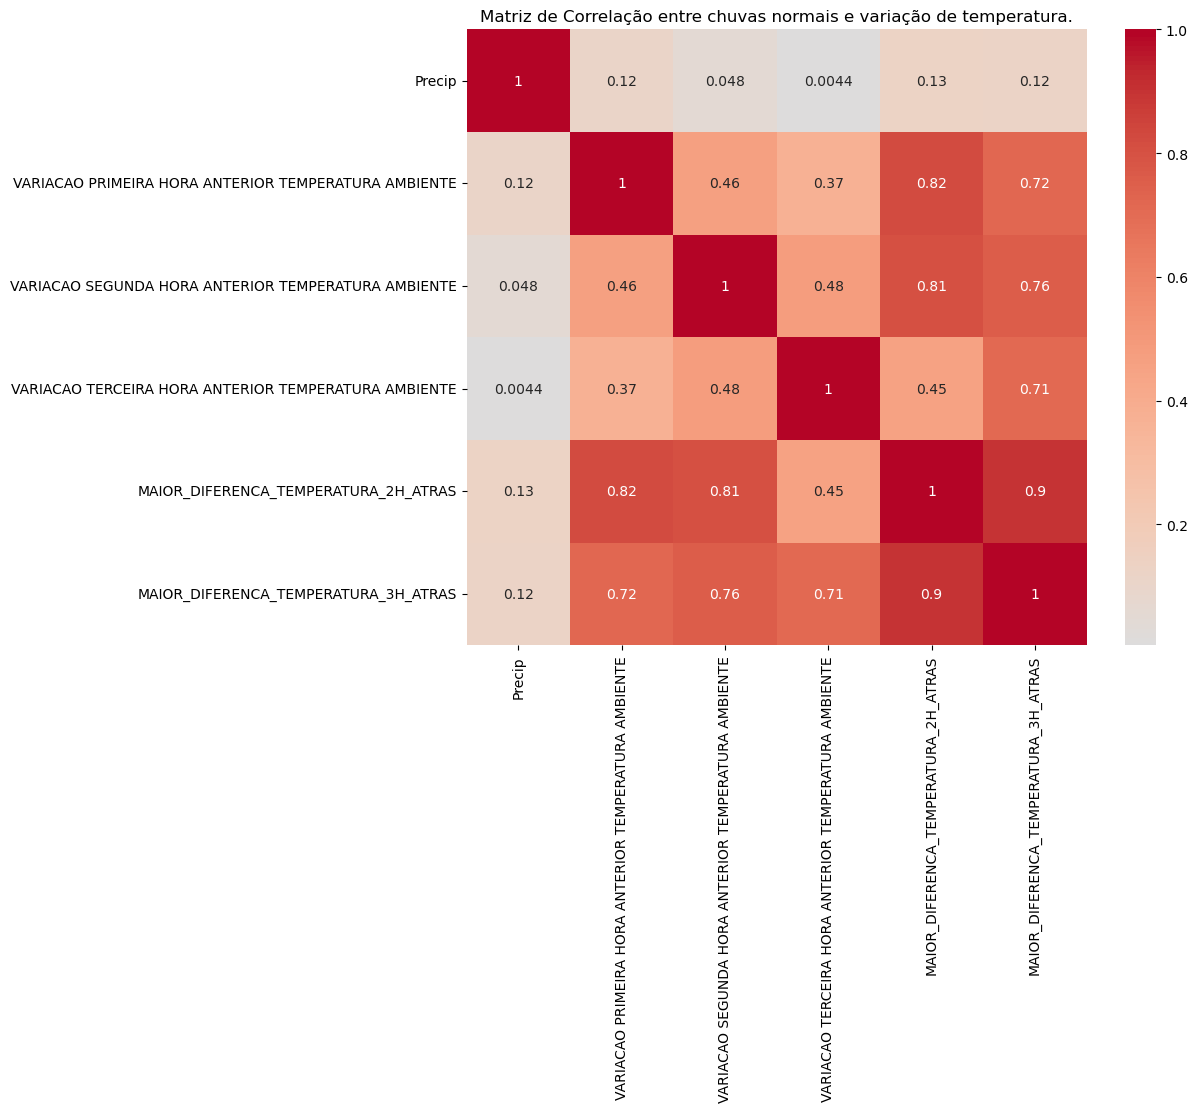

In [15]:
# Calcula a matriz de correlação
correlation_matrix = COPACABANA_CHUVA[variaveis].corr()

# Configura o tamanho da figura
plt.figure(figsize=(10, 8))

# Gera o heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)

plt.title('Matriz de Correlação entre chuvas normais e variação de temperatura.')

# Exibe o gráfico
plt.show()

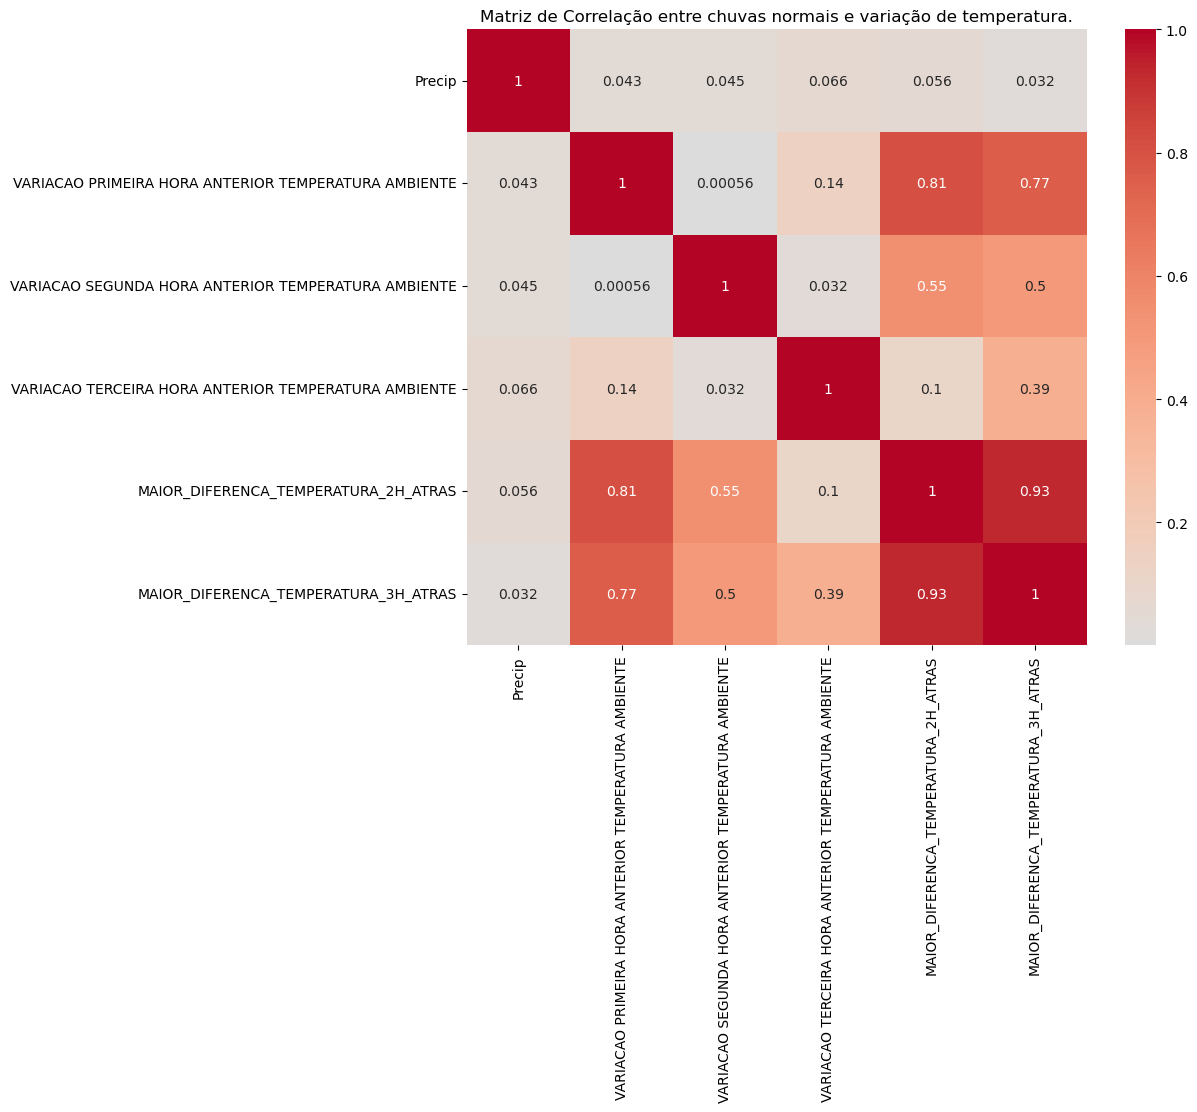

In [16]:
# Calcula a matriz de correlação
correlation_matrix = COPACABANA_CHUVA_EXTREMA[variaveis].corr()

# Configura o tamanho da figura
plt.figure(figsize=(10, 8))

# Gera o heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)

plt.title('Matriz de Correlação entre chuvas normais e variação de temperatura.')

# Exibe o gráfico
plt.show()

In [17]:
COPACABANA_CHUVA[variaveis].describe()

,Precip,VARIACAO PRIMEIRA HORA ANTERIOR TEMPERATURA AMBIENTE,VARIACAO SEGUNDA HORA ANTERIOR TEMPERATURA AMBIENTE,VARIACAO TERCEIRA HORA ANTERIOR TEMPERATURA AMBIENTE,MAIOR_DIFERENCA_TEMPERATURA_2H_ATRAS,MAIOR_DIFERENCA_TEMPERATURA_3H_ATRAS
count,12602.000000,12600.000000,12594.000000,12593.000000,12588.00000,12583.000000
mean,1.405507,0.856063,0.828577,0.811673,1.30224,1.661273
std,2.467694,0.721538,0.720589,0.707446,1.00984,1.228134
min,0.200000,0.000000,0.000000,0.000000,0.10000,0.100000
25%,0.200000,0.400000,0.400000,0.400000,0.60000,0.800000
50%,0.600000,0.600000,0.600000,0.600000,1.00000,1.300000
75%,1.400000,1.100000,1.000000,1.000000,1.70000,2.100000
max,24.800000,8.800000,10.500000,10.500000,10.80000,13.200000


In [18]:
COPACABANA_CHUVA_EXTREMA[variaveis].describe()

,Precip,VARIACAO PRIMEIRA HORA ANTERIOR TEMPERATURA AMBIENTE,VARIACAO SEGUNDA HORA ANTERIOR TEMPERATURA AMBIENTE,VARIACAO TERCEIRA HORA ANTERIOR TEMPERATURA AMBIENTE,MAIOR_DIFERENCA_TEMPERATURA_2H_ATRAS,MAIOR_DIFERENCA_TEMPERATURA_3H_ATRAS
count,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000
mean,36.804167,1.793750,1.277083,0.964583,2.727083,3.306250
std,11.505595,1.239665,1.021313,0.618677,1.645075,1.799102
min,25.200000,0.500000,0.300000,0.200000,0.600000,0.700000
25%,28.800000,0.975000,0.500000,0.500000,1.600000,1.900000
50%,33.400000,1.500000,0.900000,0.800000,2.300000,3.250000
75%,37.950000,2.325000,1.800000,1.125000,3.425000,4.025000
max,71.600000,6.800000,4.100000,2.900000,10.000000,10.600000


# Dispersão Copacabana

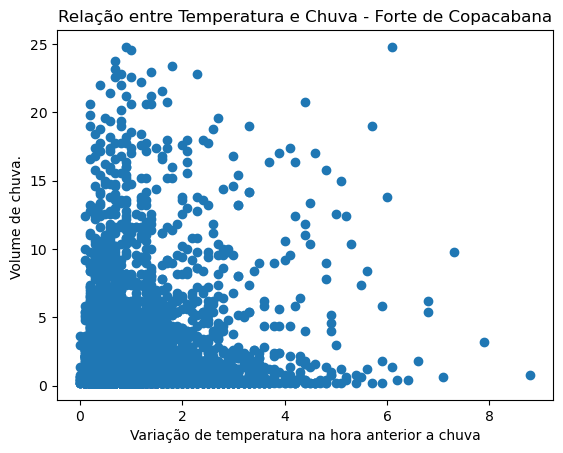

In [20]:
plt.scatter(COPACABANA_CHUVA['VARIACAO PRIMEIRA HORA ANTERIOR TEMPERATURA AMBIENTE'], COPACABANA_CHUVA['Precip'])

plt.xlabel('Variação de temperatura na hora anterior a chuva')

plt.ylabel('Volume de chuva. ')

plt.title('Relação entre Temperatura e Chuva - Forte de Copacabana')

plt.show()

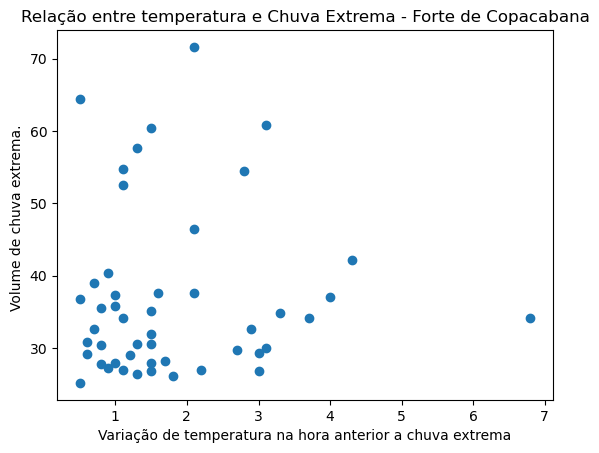

In [21]:
plt.scatter(COPACABANA_CHUVA_EXTREMA['VARIACAO PRIMEIRA HORA ANTERIOR TEMPERATURA AMBIENTE'], COPACABANA_CHUVA_EXTREMA['Precip'])

plt.xlabel('Variação de temperatura na hora anterior a chuva extrema')

plt.ylabel('Volume de chuva extrema. ')

plt.title('Relação entre temperatura e Chuva Extrema - Forte de Copacabana')

plt.show()

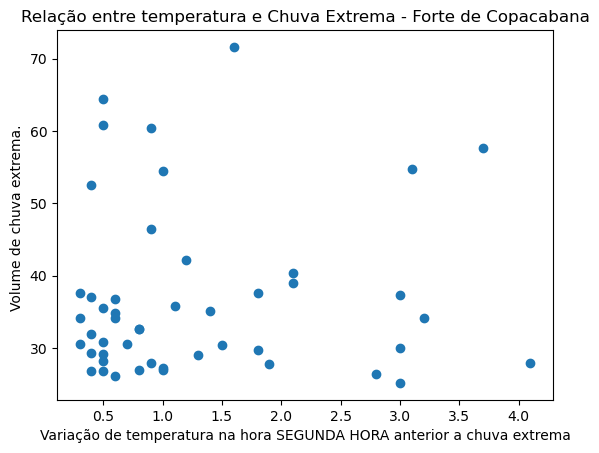

In [22]:
plt.scatter(COPACABANA_CHUVA_EXTREMA['VARIACAO SEGUNDA HORA ANTERIOR TEMPERATURA AMBIENTE'], COPACABANA_CHUVA_EXTREMA['Precip'])

plt.xlabel('Variação de temperatura na hora SEGUNDA HORA anterior a chuva extrema')

plt.ylabel('Volume de chuva extrema. ')

plt.title('Relação entre temperatura e Chuva Extrema - Forte de Copacabana')

plt.show()

# Avaliando correlação de temperatura: JACAREPAGUA.

Dt_Hr                                                     0
ESTACAO                                                   0
Precip                                                  729
Temp_Amb_max                                            743
Temp_Amb_min                                            743
VARIACAO PRIMEIRA HORA ANTERIOR TEMPERATURA AMBIENTE    698
VARIACAO SEGUNDA HORA ANTERIOR TEMPERATURA AMBIENTE     699
VARIACAO TERCEIRA HORA ANTERIOR TEMPERATURA AMBIENTE    700
dtype: int64
Total de valores nulos no DataFrame: 4312


C:\Users\Pichau\AppData\Local\Temp\ipykernel_11136\941341339.py:32: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  JACAREPAGUA = JACAREPAGUA.groupby('ESTACAO').apply(calcular_maior_diferenca).reset_index(drop=True)


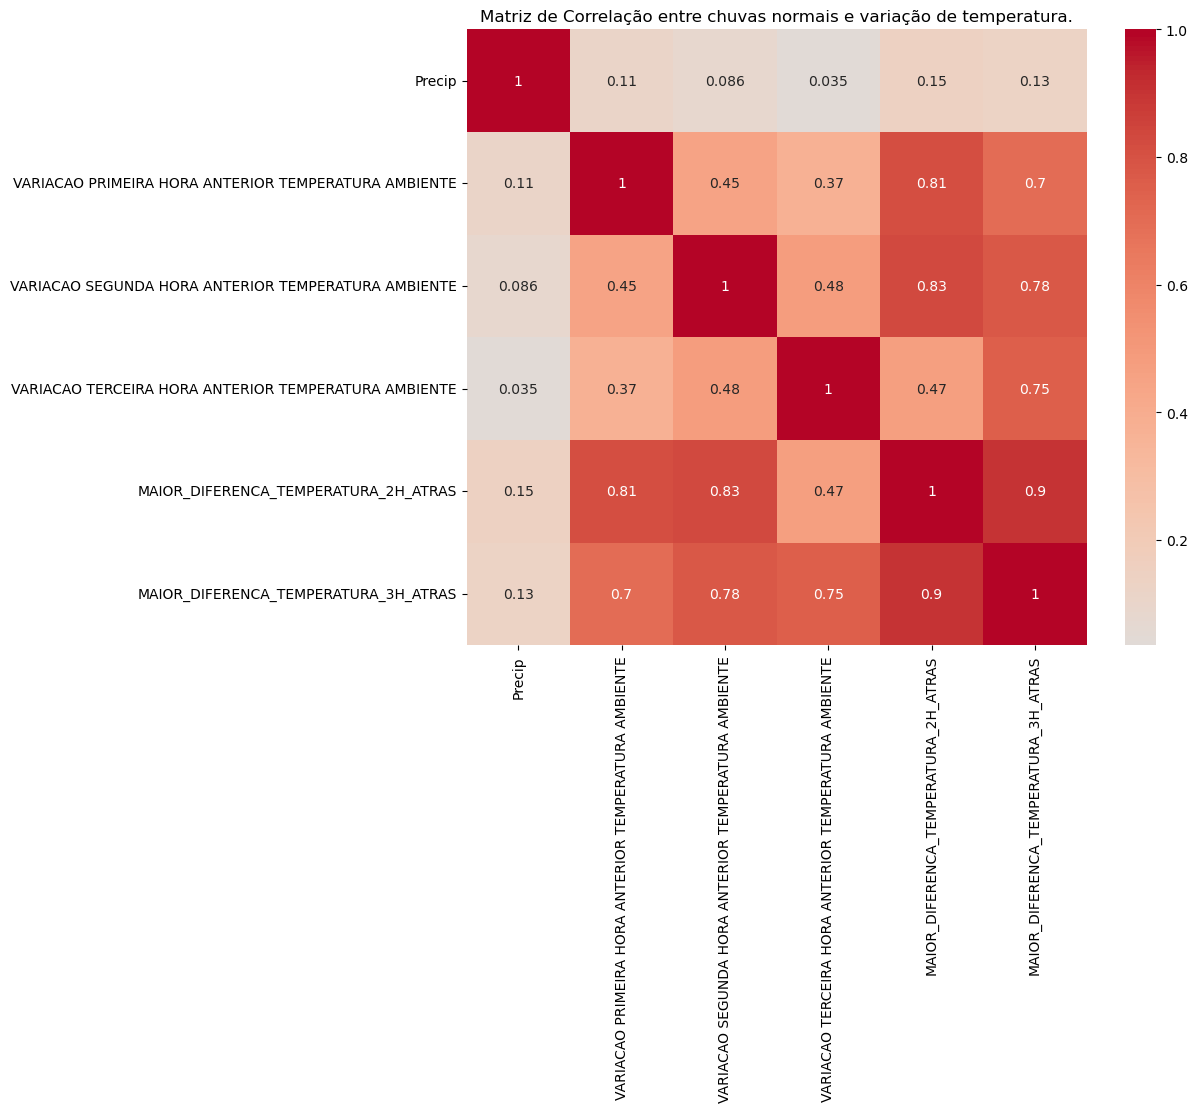

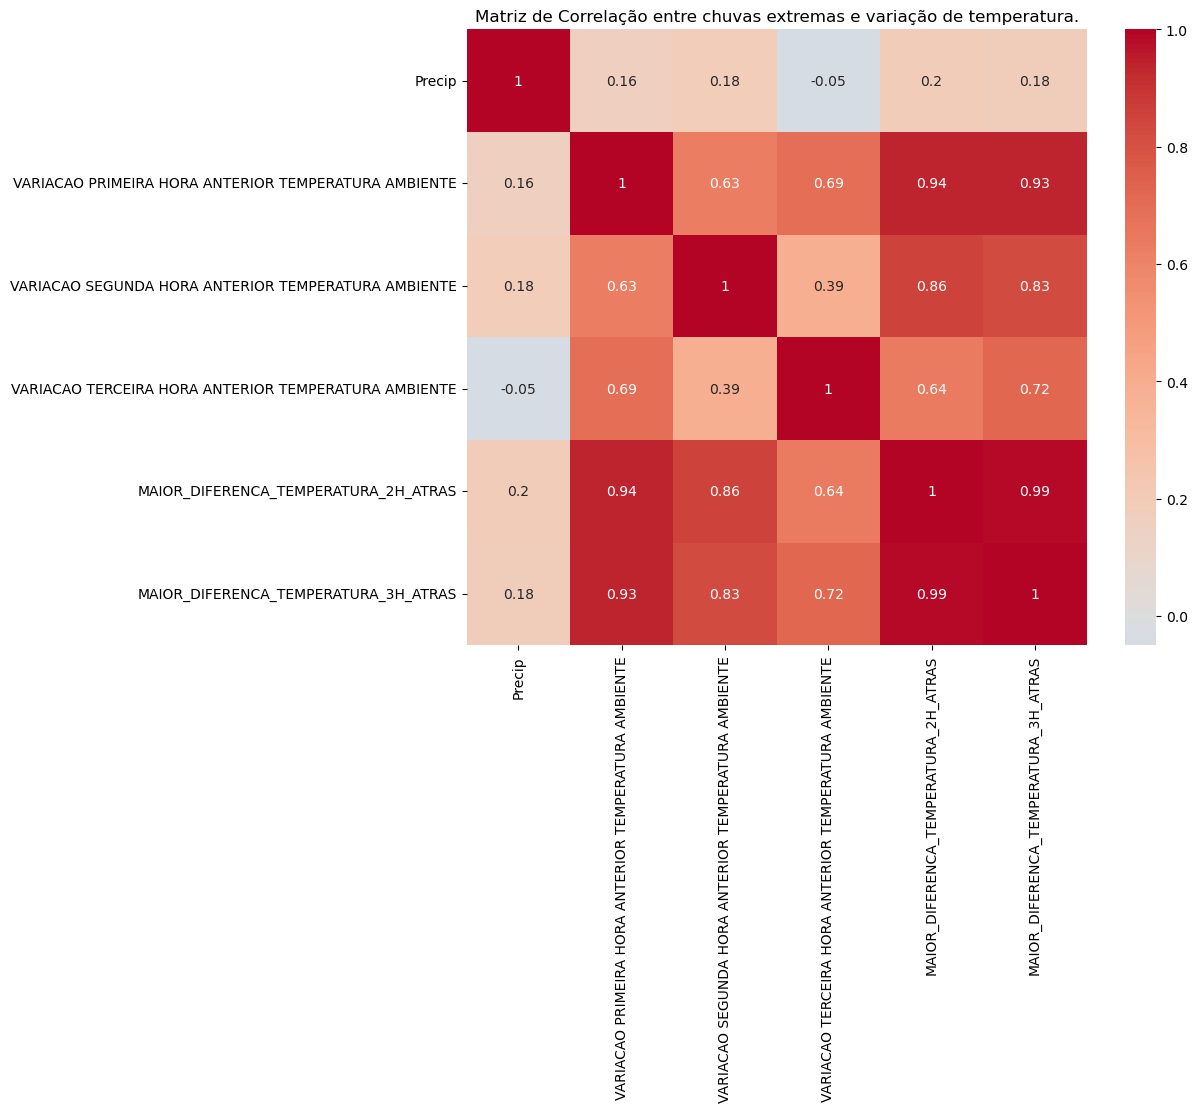

In [24]:

JACAREPAGUA = df[df['ESTACAO'] == 'JACAREPAGUA']

# Variáveis que quero usar. 
variaveis = ['Dt_Hr', 'ESTACAO','Precip', 'Temp_Amb_max','Temp_Amb_min',
           'VARIACAO PRIMEIRA HORA ANTERIOR TEMPERATURA AMBIENTE',
           'VARIACAO SEGUNDA HORA ANTERIOR TEMPERATURA AMBIENTE',
           'VARIACAO TERCEIRA HORA ANTERIOR TEMPERATURA AMBIENTE'
            ]

JACAREPAGUA = JACAREPAGUA[variaveis]


# Tirando esses nulos.

# Substitui os valores -9999 por NaN
JACAREPAGUA.replace(-9999, np.nan, inplace=True)

# Conta a quantidade de valores nulos em cada coluna
missing_values = JACAREPAGUA.isnull().sum()

# Exibe a quantidade de valores nulos
print(missing_values)

# Total de valores nulos no DataFrame
total_missing_values = JACAREPAGUA.isnull().sum().sum()
print("Total de valores nulos no DataFrame:", total_missing_values)

JACAREPAGUA = JACAREPAGUA.dropna(subset=['Precip'])

JACAREPAGUA = JACAREPAGUA.reset_index(drop=True)

JACAREPAGUA = JACAREPAGUA.groupby('ESTACAO').apply(calcular_maior_diferenca).reset_index(drop=True)

JACAREPAGUA_CHUVA = JACAREPAGUA[(JACAREPAGUA['Precip'] > 0) & (JACAREPAGUA['Precip'] < 25)]

JACAREPAGUA_CHUVA_EXTREMA = JACAREPAGUA[JACAREPAGUA['Precip'] >= 25]

variaveis = ['Precip',
           'VARIACAO PRIMEIRA HORA ANTERIOR TEMPERATURA AMBIENTE',
           'VARIACAO SEGUNDA HORA ANTERIOR TEMPERATURA AMBIENTE',
           'VARIACAO TERCEIRA HORA ANTERIOR TEMPERATURA AMBIENTE',
            'MAIOR_DIFERENCA_TEMPERATURA_2H_ATRAS',
            'MAIOR_DIFERENCA_TEMPERATURA_3H_ATRAS'
            ]

# Calcula a matriz de correlação
correlation_matrix = JACAREPAGUA_CHUVA[variaveis].corr()

# Configura o tamanho da figura
plt.figure(figsize=(10, 8))

# Gera o heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)

plt.title('Matriz de Correlação entre chuvas normais e variação de temperatura.')

# Exibe o gráfico
plt.show()


# Calcula a matriz de correlação
correlation_matrix = JACAREPAGUA_CHUVA_EXTREMA[variaveis].corr()

# Configura o tamanho da figura
plt.figure(figsize=(10, 8))

# Gera o heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)

plt.title('Matriz de Correlação entre chuvas extremas e variação de temperatura.')

# Exibe o gráfico
plt.show()


In [74]:
JACAREPAGUA_CHUVA[variaveis].describe()

,Precip,VARIACAO PRIMEIRA HORA ANTERIOR TEMPERATURA AMBIENTE,VARIACAO SEGUNDA HORA ANTERIOR TEMPERATURA AMBIENTE,VARIACAO TERCEIRA HORA ANTERIOR TEMPERATURA AMBIENTE,MAIOR_DIFERENCA_TEMPERATURA_2H_ATRAS,MAIOR_DIFERENCA_TEMPERATURA_3H_ATRAS
count,5635.000000,5634.000000,5623.000000,5616.000000,5633.000000,5633.000000
mean,1.739840,0.781328,0.784457,0.809028,1.281768,1.743121
std,2.863794,0.773328,0.759346,0.770416,1.172841,1.521743
min,0.200000,0.000000,0.000000,0.000000,0.100000,0.100000
25%,0.200000,0.300000,0.300000,0.300000,0.500000,0.700000
50%,0.600000,0.500000,0.600000,0.600000,0.900000,1.300000
75%,2.000000,1.000000,1.000000,1.000000,1.600000,2.200000
max,24.800000,12.100000,12.100000,12.100000,14.700000,15.300000


In [76]:
JACAREPAGUA_CHUVA_EXTREMA[variaveis].describe()

,Precip,VARIACAO PRIMEIRA HORA ANTERIOR TEMPERATURA AMBIENTE,VARIACAO SEGUNDA HORA ANTERIOR TEMPERATURA AMBIENTE,VARIACAO TERCEIRA HORA ANTERIOR TEMPERATURA AMBIENTE,MAIOR_DIFERENCA_TEMPERATURA_2H_ATRAS,MAIOR_DIFERENCA_TEMPERATURA_3H_ATRAS
count,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000
mean,35.548387,1.800000,1.229032,0.912903,2.906452,3.445161
std,11.095461,1.873499,1.239676,0.620076,2.889168,3.134628
min,25.200000,0.200000,0.100000,0.100000,0.400000,0.400000
25%,28.400000,0.750000,0.400000,0.450000,1.050000,1.300000
50%,32.000000,1.200000,0.800000,0.900000,2.000000,2.200000
75%,38.600000,2.350000,1.650000,1.050000,3.650000,4.550000
max,80.200000,9.700000,5.200000,2.600000,15.000000,15.400000


# Dispersão JACAREPAGUA 


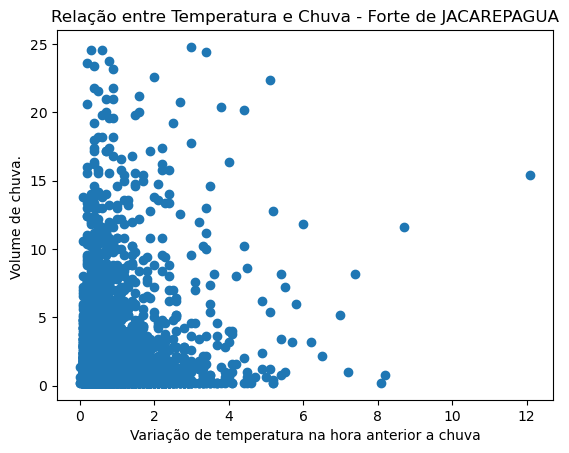

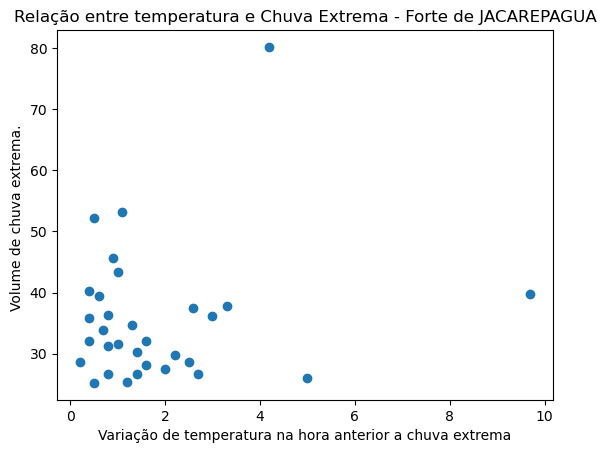

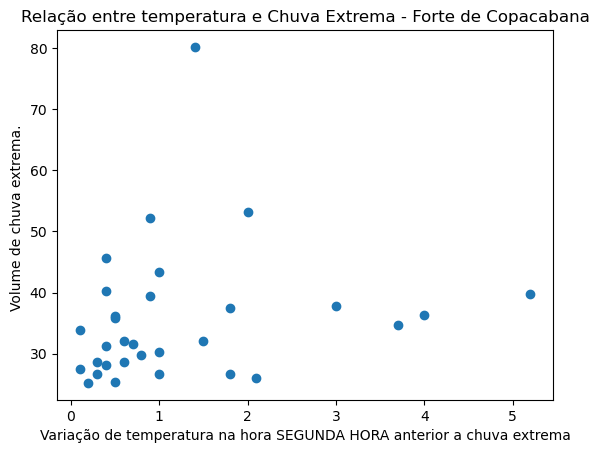

In [26]:


plt.scatter(JACAREPAGUA_CHUVA['VARIACAO PRIMEIRA HORA ANTERIOR TEMPERATURA AMBIENTE'], JACAREPAGUA_CHUVA['Precip'])

plt.xlabel('Variação de temperatura na hora anterior a chuva')

plt.ylabel('Volume de chuva. ')

plt.title('Relação entre Temperatura e Chuva - Forte de JACAREPAGUA')

plt.show() 


plt.scatter(JACAREPAGUA_CHUVA_EXTREMA['VARIACAO PRIMEIRA HORA ANTERIOR TEMPERATURA AMBIENTE'], JACAREPAGUA_CHUVA_EXTREMA['Precip'])

plt.xlabel('Variação de temperatura na hora anterior a chuva extrema')

plt.ylabel('Volume de chuva extrema. ')

plt.title('Relação entre temperatura e Chuva Extrema - Forte de JACAREPAGUA')

plt.show()




plt.scatter(JACAREPAGUA_CHUVA_EXTREMA['VARIACAO SEGUNDA HORA ANTERIOR TEMPERATURA AMBIENTE'], JACAREPAGUA_CHUVA_EXTREMA['Precip'])

plt.xlabel('Variação de temperatura na hora SEGUNDA HORA anterior a chuva extrema')

plt.ylabel('Volume de chuva extrema. ')

plt.title('Relação entre temperatura e Chuva Extrema - Forte de Copacabana')

plt.show()

# Avaliação de correlação de Temperatura: MARAMBAIA

Dt_Hr                                                       0
ESTACAO                                                     0
Precip                                                  17701
Temp_Amb_max                                            16507
Temp_Amb_min                                            16507
VARIACAO PRIMEIRA HORA ANTERIOR TEMPERATURA AMBIENTE      553
VARIACAO SEGUNDA HORA ANTERIOR TEMPERATURA AMBIENTE       554
VARIACAO TERCEIRA HORA ANTERIOR TEMPERATURA AMBIENTE      555
dtype: int64
Total de valores nulos no DataFrame: 52377


C:\Users\Pichau\AppData\Local\Temp\ipykernel_11136\4147604324.py:32: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  MARAMBAIA = MARAMBAIA.groupby('ESTACAO').apply(calcular_maior_diferenca).reset_index(drop=True)


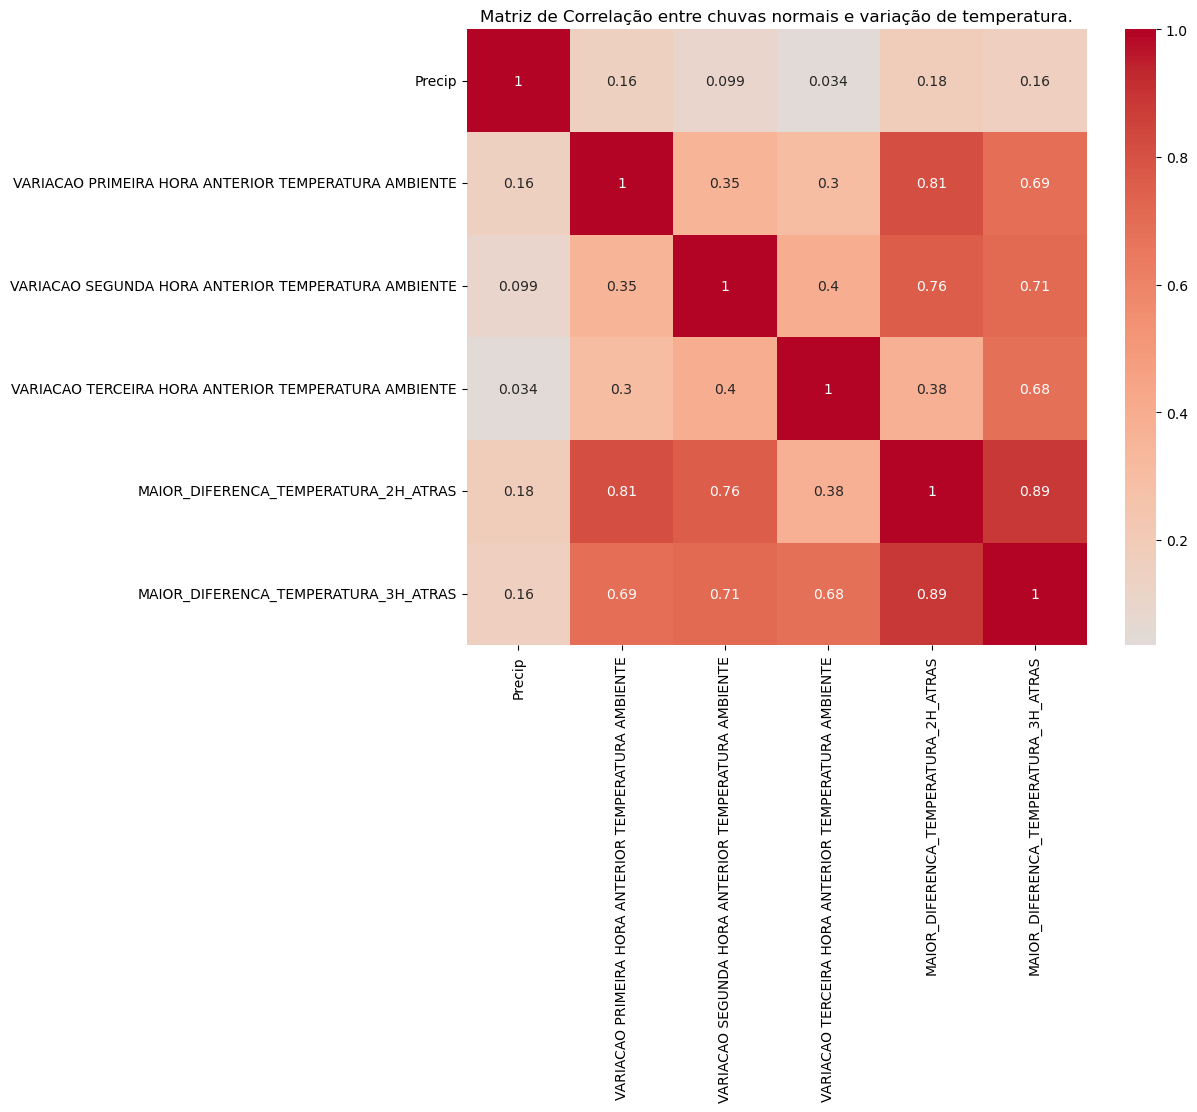

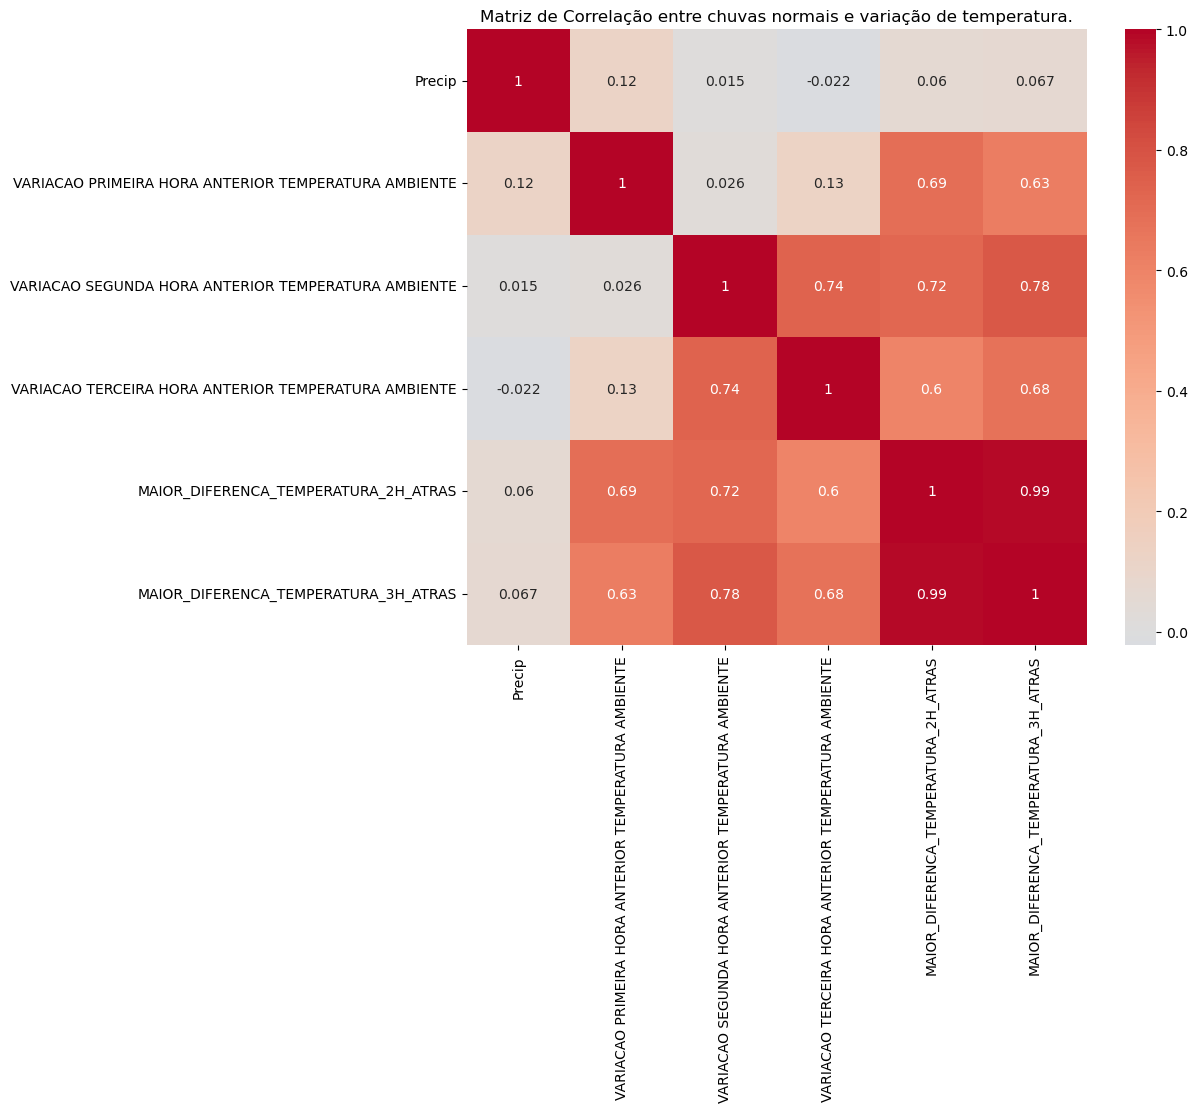

,Precip,VARIACAO PRIMEIRA HORA ANTERIOR TEMPERATURA AMBIENTE,VARIACAO SEGUNDA HORA ANTERIOR TEMPERATURA AMBIENTE,VARIACAO TERCEIRA HORA ANTERIOR TEMPERATURA AMBIENTE,MAIOR_DIFERENCA_TEMPERATURA_2H_ATRAS,MAIOR_DIFERENCA_TEMPERATURA_3H_ATRAS
count,46.000000,46.000000,46.000000,46.000000,46.000000,46.000000
mean,39.343478,2.091304,1.539130,0.923913,3.328261,3.769565
std,15.180904,1.705394,1.786925,0.825748,2.497702,2.797687
min,25.200000,0.300000,0.100000,0.100000,0.600000,1.100000
25%,29.500000,0.900000,0.600000,0.400000,1.400000,1.700000
50%,35.000000,1.450000,0.900000,0.700000,2.500000,2.800000
75%,42.950000,2.975000,1.550000,1.175000,4.775000,4.975000
max,97.200000,7.200000,8.800000,4.900000,9.700000,12.000000


In [28]:

MARAMBAIA = df[df['ESTACAO'] == 'MARAMBAIA']

# Variáveis que quero usar. 
variaveis = ['Dt_Hr', 'ESTACAO','Precip', 'Temp_Amb_max','Temp_Amb_min',
           'VARIACAO PRIMEIRA HORA ANTERIOR TEMPERATURA AMBIENTE',
           'VARIACAO SEGUNDA HORA ANTERIOR TEMPERATURA AMBIENTE',
           'VARIACAO TERCEIRA HORA ANTERIOR TEMPERATURA AMBIENTE'
            ]

MARAMBAIA = MARAMBAIA[variaveis]


# Tirando esses nulos.

# Substitui os valores -9999 por NaN
MARAMBAIA.replace(-9999, np.nan, inplace=True)

# Conta a quantidade de valores nulos em cada coluna
missing_values = MARAMBAIA.isnull().sum()

# Exibe a quantidade de valores nulos
print(missing_values)

# Total de valores nulos no DataFrame
total_missing_values = MARAMBAIA.isnull().sum().sum()
print("Total de valores nulos no DataFrame:", total_missing_values)

MARAMBAIA = MARAMBAIA.dropna(subset=['Precip'])

MARAMBAIA = MARAMBAIA.reset_index(drop=True)

MARAMBAIA = MARAMBAIA.groupby('ESTACAO').apply(calcular_maior_diferenca).reset_index(drop=True)

MARAMBAIA_CHUVA = MARAMBAIA[(MARAMBAIA['Precip'] > 0) & (MARAMBAIA['Precip'] < 25)]

MARAMBAIA_CHUVA_EXTREMA = MARAMBAIA[MARAMBAIA['Precip'] >= 25]

variaveis = ['Precip',
           'VARIACAO PRIMEIRA HORA ANTERIOR TEMPERATURA AMBIENTE',
           'VARIACAO SEGUNDA HORA ANTERIOR TEMPERATURA AMBIENTE',
           'VARIACAO TERCEIRA HORA ANTERIOR TEMPERATURA AMBIENTE',
            'MAIOR_DIFERENCA_TEMPERATURA_2H_ATRAS',
            'MAIOR_DIFERENCA_TEMPERATURA_3H_ATRAS'
            ]

# Calcula a matriz de correlação
correlation_matrix = MARAMBAIA_CHUVA[variaveis].corr()

# Configura o tamanho da figura
plt.figure(figsize=(10, 8))

# Gera o heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)

plt.title('Matriz de Correlação entre chuvas normais e variação de temperatura.')

# Exibe o gráfico
plt.show()


# Calcula a matriz de correlação
correlation_matrix = MARAMBAIA_CHUVA_EXTREMA[variaveis].corr()

# Configura o tamanho da figura
plt.figure(figsize=(10, 8))

# Gera o heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)

plt.title('Matriz de Correlação entre chuvas normais e variação de temperatura.')

# Exibe o gráfico
plt.show()


MARAMBAIA_CHUVA[variaveis].describe()


MARAMBAIA_CHUVA_EXTREMA[variaveis].describe()




In [80]:
MARAMBAIA_CHUVA[variaveis].describe()

,Precip,VARIACAO PRIMEIRA HORA ANTERIOR TEMPERATURA AMBIENTE,VARIACAO SEGUNDA HORA ANTERIOR TEMPERATURA AMBIENTE,VARIACAO TERCEIRA HORA ANTERIOR TEMPERATURA AMBIENTE,MAIOR_DIFERENCA_TEMPERATURA_2H_ATRAS,MAIOR_DIFERENCA_TEMPERATURA_3H_ATRAS
count,13736.000000,13714.000000,13712.000000,13701.000000,13633.000000,13629.000000
mean,1.485847,0.841972,0.806381,0.790373,1.297462,1.663600
std,2.501179,0.835731,0.810783,0.781261,1.143515,1.394025
min,0.200000,0.000000,0.000000,0.000000,0.100000,0.100000
25%,0.200000,0.400000,0.300000,0.300000,0.600000,0.800000
50%,0.600000,0.600000,0.600000,0.600000,1.000000,1.300000
75%,1.600000,1.100000,1.000000,1.000000,1.600000,2.000000
max,24.600000,29.900000,29.900000,14.300000,29.900000,29.900000


In [82]:
MARAMBAIA_CHUVA[variaveis].describe()

,Precip,VARIACAO PRIMEIRA HORA ANTERIOR TEMPERATURA AMBIENTE,VARIACAO SEGUNDA HORA ANTERIOR TEMPERATURA AMBIENTE,VARIACAO TERCEIRA HORA ANTERIOR TEMPERATURA AMBIENTE,MAIOR_DIFERENCA_TEMPERATURA_2H_ATRAS,MAIOR_DIFERENCA_TEMPERATURA_3H_ATRAS
count,13736.000000,13714.000000,13712.000000,13701.000000,13633.000000,13629.000000
mean,1.485847,0.841972,0.806381,0.790373,1.297462,1.663600
std,2.501179,0.835731,0.810783,0.781261,1.143515,1.394025
min,0.200000,0.000000,0.000000,0.000000,0.100000,0.100000
25%,0.200000,0.400000,0.300000,0.300000,0.600000,0.800000
50%,0.600000,0.600000,0.600000,0.600000,1.000000,1.300000
75%,1.600000,1.100000,1.000000,1.000000,1.600000,2.000000
max,24.600000,29.900000,29.900000,14.300000,29.900000,29.900000


In [84]:
MARAMBAIA_CHUVA_EXTREMA[variaveis].describe()

,Precip,VARIACAO PRIMEIRA HORA ANTERIOR TEMPERATURA AMBIENTE,VARIACAO SEGUNDA HORA ANTERIOR TEMPERATURA AMBIENTE,VARIACAO TERCEIRA HORA ANTERIOR TEMPERATURA AMBIENTE,MAIOR_DIFERENCA_TEMPERATURA_2H_ATRAS,MAIOR_DIFERENCA_TEMPERATURA_3H_ATRAS
count,46.000000,46.000000,46.000000,46.000000,46.000000,46.000000
mean,39.343478,2.091304,1.539130,0.923913,3.328261,3.769565
std,15.180904,1.705394,1.786925,0.825748,2.497702,2.797687
min,25.200000,0.300000,0.100000,0.100000,0.600000,1.100000
25%,29.500000,0.900000,0.600000,0.400000,1.400000,1.700000
50%,35.000000,1.450000,0.900000,0.700000,2.500000,2.800000
75%,42.950000,2.975000,1.550000,1.175000,4.775000,4.975000
max,97.200000,7.200000,8.800000,4.900000,9.700000,12.000000


# Dispersão MARAMBAIA 

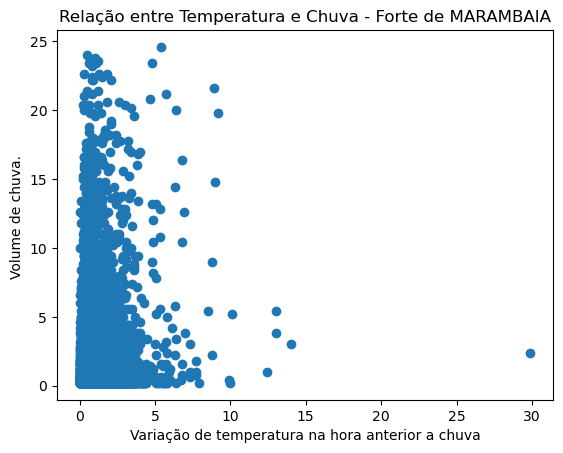

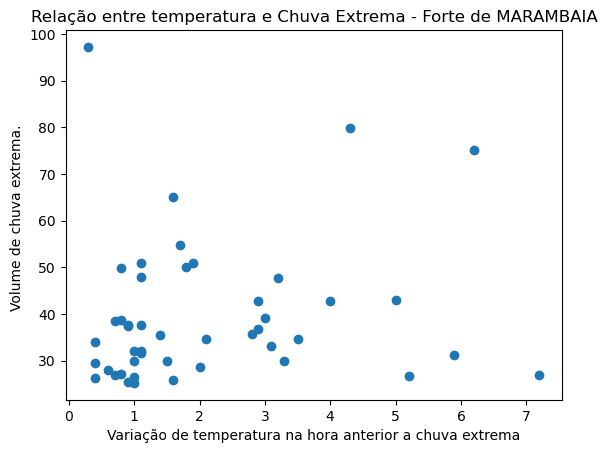

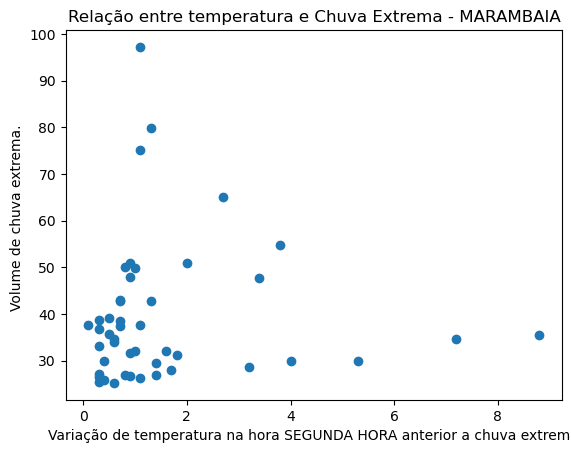

In [86]:

plt.scatter(MARAMBAIA_CHUVA['VARIACAO PRIMEIRA HORA ANTERIOR TEMPERATURA AMBIENTE'], MARAMBAIA_CHUVA['Precip'])

plt.xlabel('Variação de temperatura na hora anterior a chuva')

plt.ylabel('Volume de chuva. ')

plt.title('Relação entre Temperatura e Chuva - Forte de MARAMBAIA')

plt.show() 


plt.scatter(MARAMBAIA_CHUVA_EXTREMA['VARIACAO PRIMEIRA HORA ANTERIOR TEMPERATURA AMBIENTE'], MARAMBAIA_CHUVA_EXTREMA['Precip'])

plt.xlabel('Variação de temperatura na hora anterior a chuva extrema')

plt.ylabel('Volume de chuva extrema. ')

plt.title('Relação entre temperatura e Chuva Extrema - Forte de MARAMBAIA')

plt.show()


plt.scatter(MARAMBAIA_CHUVA_EXTREMA['VARIACAO SEGUNDA HORA ANTERIOR TEMPERATURA AMBIENTE'], MARAMBAIA_CHUVA_EXTREMA['Precip'])

plt.xlabel('Variação de temperatura na hora SEGUNDA HORA anterior a chuva extrema')

plt.ylabel('Volume de chuva extrema. ')

plt.title('Relação entre temperatura e Chuva Extrema - MARAMBAIA')

plt.show()

# Avaliando correlação de temperatura: VILA MILITAR.

Dt_Hr                                                      0
ESTACAO                                                    0
Precip                                                  5709
Temp_Amb_max                                            5015
Temp_Amb_min                                            5016
VARIACAO PRIMEIRA HORA ANTERIOR TEMPERATURA AMBIENTE    1238
VARIACAO SEGUNDA HORA ANTERIOR TEMPERATURA AMBIENTE     1239
VARIACAO TERCEIRA HORA ANTERIOR TEMPERATURA AMBIENTE    1240
dtype: int64
Total de valores nulos no DataFrame: 19457


C:\Users\Pichau\AppData\Local\Temp\ipykernel_11136\1694931543.py:32: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  VILA_MILITAR = VILA_MILITAR.groupby('ESTACAO').apply(calcular_maior_diferenca).reset_index(drop=True)


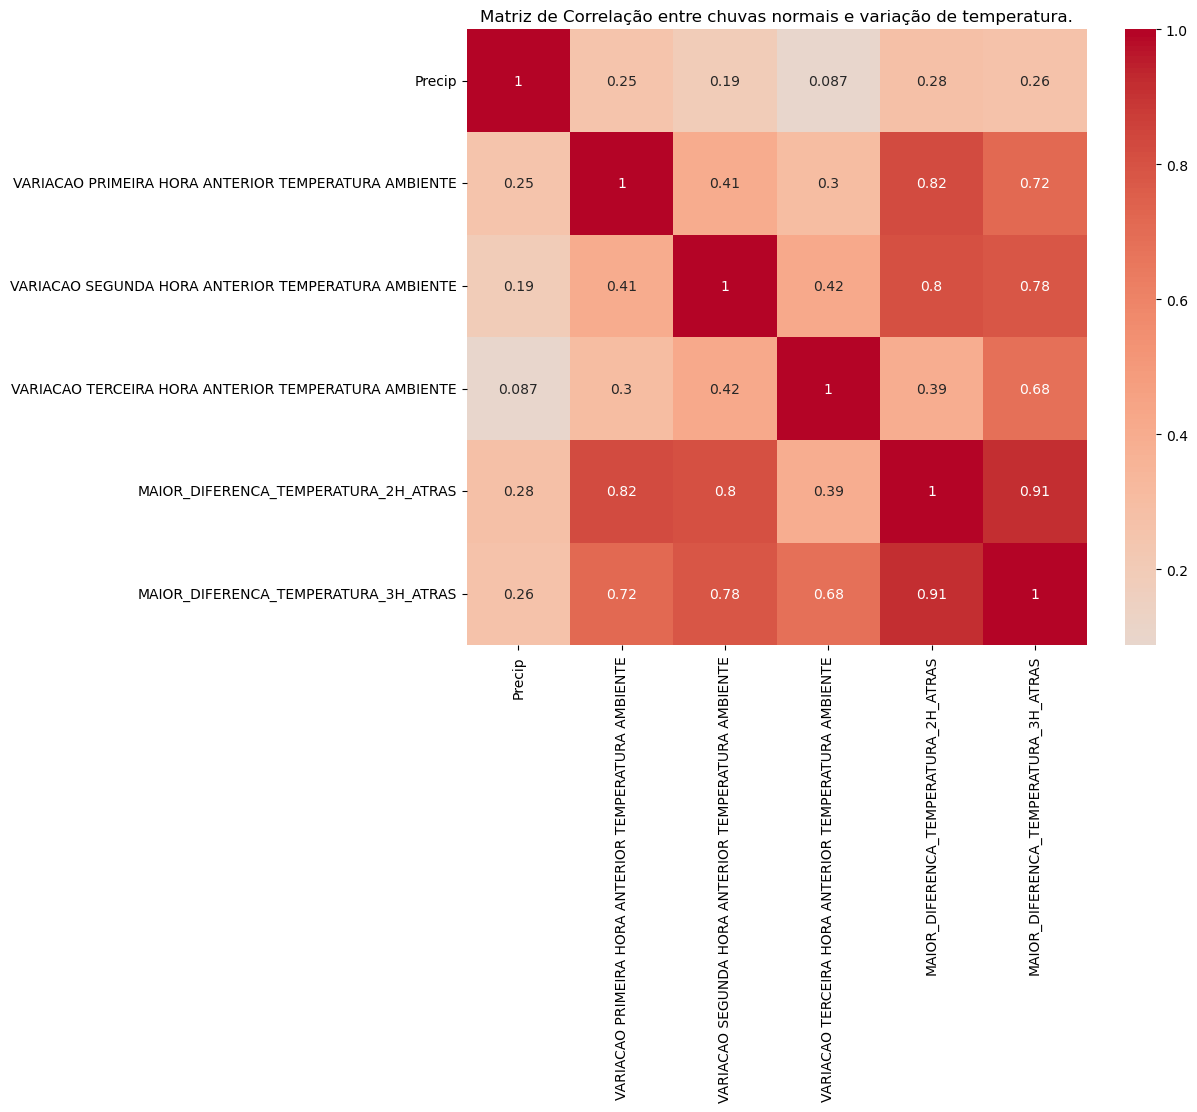

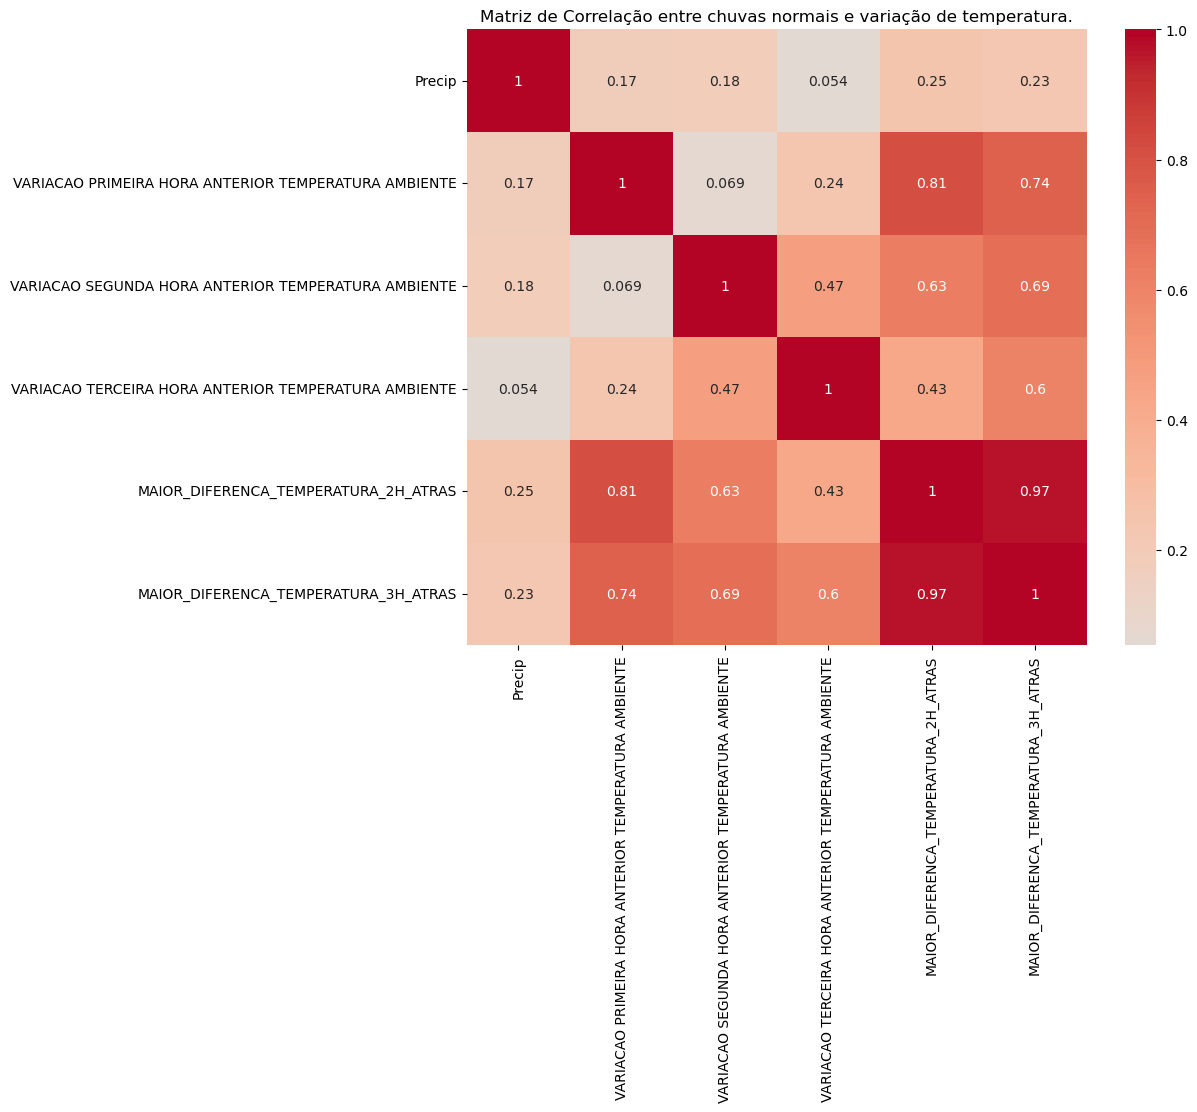

,Precip,VARIACAO PRIMEIRA HORA ANTERIOR TEMPERATURA AMBIENTE,VARIACAO SEGUNDA HORA ANTERIOR TEMPERATURA AMBIENTE,VARIACAO TERCEIRA HORA ANTERIOR TEMPERATURA AMBIENTE,MAIOR_DIFERENCA_TEMPERATURA_2H_ATRAS,MAIOR_DIFERENCA_TEMPERATURA_3H_ATRAS
count,74.000000,74.000000,74.000000,74.000000,74.000000,74.000000
mean,35.113514,3.291892,2.368919,1.318919,5.413514,6.298649
std,8.705853,3.086105,2.522117,1.022845,3.959740,4.308752
min,25.000000,0.300000,0.100000,0.100000,0.500000,0.600000
25%,29.000000,1.000000,0.700000,0.600000,2.500000,2.775000
50%,32.100000,2.300000,1.600000,1.000000,4.450000,5.650000
75%,40.400000,4.675000,2.975000,1.700000,7.375000,8.700000
max,64.000000,13.000000,13.100000,4.600000,15.000000,16.300000


In [32]:

VILA_MILITAR = df[df['ESTACAO'] == 'VILA_MILITAR']

# Variáveis que quero usar. 
variaveis = ['Dt_Hr', 'ESTACAO','Precip', 'Temp_Amb_max','Temp_Amb_min',
           'VARIACAO PRIMEIRA HORA ANTERIOR TEMPERATURA AMBIENTE',
           'VARIACAO SEGUNDA HORA ANTERIOR TEMPERATURA AMBIENTE',
           'VARIACAO TERCEIRA HORA ANTERIOR TEMPERATURA AMBIENTE'
            ]

VILA_MILITAR = VILA_MILITAR[variaveis]


# Tirando esses nulos.

# Substitui os valores -9999 por NaN
VILA_MILITAR.replace(-9999, np.nan, inplace=True)

# Conta a quantidade de valores nulos em cada coluna
missing_values = VILA_MILITAR.isnull().sum()

# Exibe a quantidade de valores nulos
print(missing_values)

# Total de valores nulos no DataFrame
total_missing_values = VILA_MILITAR.isnull().sum().sum()
print("Total de valores nulos no DataFrame:", total_missing_values)

VILA_MILITAR = VILA_MILITAR.dropna(subset=['Precip'])

VILA_MILITAR = VILA_MILITAR.reset_index(drop=True)

VILA_MILITAR = VILA_MILITAR.groupby('ESTACAO').apply(calcular_maior_diferenca).reset_index(drop=True)

VILA_MILITAR_CHUVA = VILA_MILITAR[(VILA_MILITAR['Precip'] > 0) & (VILA_MILITAR['Precip'] < 25)]

VILA_MILITAR_CHUVA_EXTREMA = VILA_MILITAR[VILA_MILITAR['Precip'] >= 25]

variaveis = ['Precip',
           'VARIACAO PRIMEIRA HORA ANTERIOR TEMPERATURA AMBIENTE',
           'VARIACAO SEGUNDA HORA ANTERIOR TEMPERATURA AMBIENTE',
           'VARIACAO TERCEIRA HORA ANTERIOR TEMPERATURA AMBIENTE',
            'MAIOR_DIFERENCA_TEMPERATURA_2H_ATRAS',
            'MAIOR_DIFERENCA_TEMPERATURA_3H_ATRAS'
            ]

# Calcula a matriz de correlação
correlation_matrix = VILA_MILITAR_CHUVA[variaveis].corr()

# Configura o tamanho da figura
plt.figure(figsize=(10, 8))

# Gera o heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)

plt.title('Matriz de Correlação entre chuvas normais e variação de temperatura.')

# Exibe o gráfico
plt.show()


# Calcula a matriz de correlação
correlation_matrix = VILA_MILITAR_CHUVA_EXTREMA[variaveis].corr()

# Configura o tamanho da figura
plt.figure(figsize=(10, 8))

# Gera o heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)

plt.title('Matriz de Correlação entre chuvas normais e variação de temperatura.')

# Exibe o gráfico
plt.show()


VILA_MILITAR_CHUVA[variaveis].describe()


VILA_MILITAR_CHUVA_EXTREMA[variaveis].describe()

In [88]:
VILA_MILITAR_CHUVA[variaveis].describe()

,Precip,VARIACAO PRIMEIRA HORA ANTERIOR TEMPERATURA AMBIENTE,VARIACAO SEGUNDA HORA ANTERIOR TEMPERATURA AMBIENTE,VARIACAO TERCEIRA HORA ANTERIOR TEMPERATURA AMBIENTE,MAIOR_DIFERENCA_TEMPERATURA_2H_ATRAS,MAIOR_DIFERENCA_TEMPERATURA_3H_ATRAS
count,11532.000000,11527.000000,11522.000000,11518.000000,11524.000000,11522.000000
mean,1.493757,0.908215,0.921793,0.897022,1.534780,2.070430
std,2.700741,1.012420,1.024424,0.918512,1.581871,1.977314
min,0.200000,0.000000,0.000000,0.000000,0.100000,0.100000
25%,0.200000,0.300000,0.300000,0.400000,0.600000,0.800000
50%,0.400000,0.600000,0.600000,0.600000,1.000000,1.400000
75%,1.400000,1.100000,1.100000,1.100000,1.900000,2.600000
max,24.800000,15.000000,15.000000,15.000000,18.700000,18.700000


In [90]:
VILA_MILITAR_CHUVA_EXTREMA[variaveis].describe()

,Precip,VARIACAO PRIMEIRA HORA ANTERIOR TEMPERATURA AMBIENTE,VARIACAO SEGUNDA HORA ANTERIOR TEMPERATURA AMBIENTE,VARIACAO TERCEIRA HORA ANTERIOR TEMPERATURA AMBIENTE,MAIOR_DIFERENCA_TEMPERATURA_2H_ATRAS,MAIOR_DIFERENCA_TEMPERATURA_3H_ATRAS
count,74.000000,74.000000,74.000000,74.000000,74.000000,74.000000
mean,35.113514,3.291892,2.368919,1.318919,5.413514,6.298649
std,8.705853,3.086105,2.522117,1.022845,3.959740,4.308752
min,25.000000,0.300000,0.100000,0.100000,0.500000,0.600000
25%,29.000000,1.000000,0.700000,0.600000,2.500000,2.775000
50%,32.100000,2.300000,1.600000,1.000000,4.450000,5.650000
75%,40.400000,4.675000,2.975000,1.700000,7.375000,8.700000
max,64.000000,13.000000,13.100000,4.600000,15.000000,16.300000


# Dispersão VILA_MILITAR

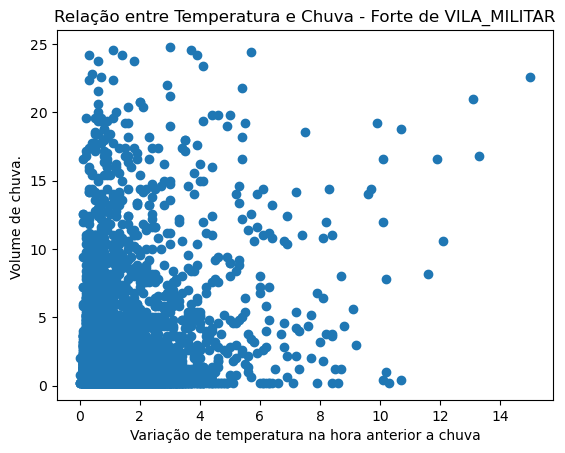

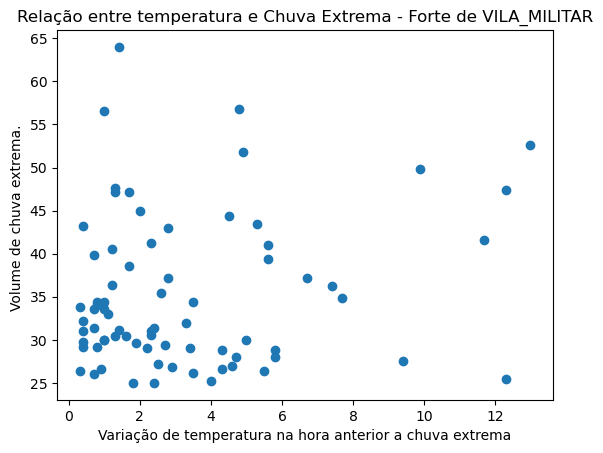

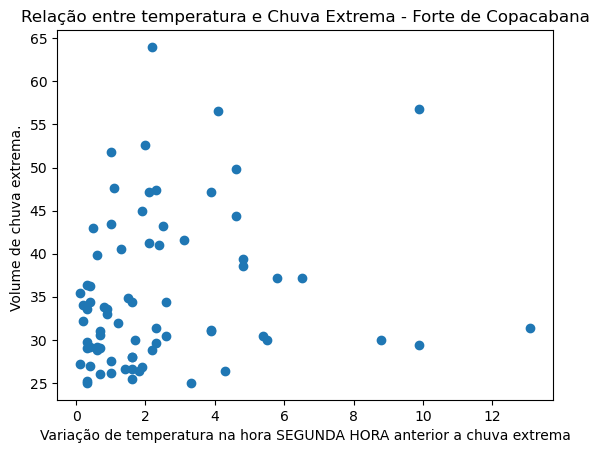

In [34]:
plt.scatter(VILA_MILITAR_CHUVA['VARIACAO PRIMEIRA HORA ANTERIOR TEMPERATURA AMBIENTE'], VILA_MILITAR_CHUVA['Precip'])

plt.xlabel('Variação de temperatura na hora anterior a chuva')

plt.ylabel('Volume de chuva. ')

plt.title('Relação entre Temperatura e Chuva - Forte de VILA_MILITAR')

plt.show() 


plt.scatter(VILA_MILITAR_CHUVA_EXTREMA['VARIACAO PRIMEIRA HORA ANTERIOR TEMPERATURA AMBIENTE'], VILA_MILITAR_CHUVA_EXTREMA['Precip'])

plt.xlabel('Variação de temperatura na hora anterior a chuva extrema')

plt.ylabel('Volume de chuva extrema. ')

plt.title('Relação entre temperatura e Chuva Extrema - Forte de VILA_MILITAR')

plt.show()




plt.scatter(VILA_MILITAR_CHUVA_EXTREMA['VARIACAO SEGUNDA HORA ANTERIOR TEMPERATURA AMBIENTE'], VILA_MILITAR_CHUVA_EXTREMA['Precip'])

plt.xlabel('Variação de temperatura na hora SEGUNDA HORA anterior a chuva extrema')

plt.ylabel('Volume de chuva extrema. ')

plt.title('Relação entre temperatura e Chuva Extrema - Forte de Copacabana')

plt.show()

In [35]:


VILA_MILITAR_CHUVA_EXTREMA['VARIACAO PRIMEIRA HORA ANTERIOR TEMPERATURA AMBIENTE'].describe()

count    74.000000
mean      3.291892
std       3.086105
min       0.300000
25%       1.000000
50%       2.300000
75%       4.675000
max      13.000000
Name: VARIACAO PRIMEIRA HORA ANTERIOR TEMPERATURA AMBIENTE, dtype: float64

In [36]:
COPACABANA_CHUVA_EXTREMA['VARIACAO PRIMEIRA HORA ANTERIOR TEMPERATURA AMBIENTE'].describe()

count    48.000000
mean      1.793750
std       1.239665
min       0.500000
25%       0.975000
50%       1.500000
75%       2.325000
max       6.800000
Name: VARIACAO PRIMEIRA HORA ANTERIOR TEMPERATURA AMBIENTE, dtype: float64

In [37]:
COPACABANA_CHUVA['VARIACAO PRIMEIRA HORA ANTERIOR TEMPERATURA AMBIENTE'].describe()

count    12600.000000
mean         0.856063
std          0.721538
min          0.000000
25%          0.400000
50%          0.600000
75%          1.100000
max          8.800000
Name: VARIACAO PRIMEIRA HORA ANTERIOR TEMPERATURA AMBIENTE, dtype: float64

In [38]:

print("Estatísticas Descritivas da Variação Primeira Hora Anterior da Temperatura Ambiente - Copacabana - Chuva Normal")

print(COPACABANA_CHUVA['VARIACAO PRIMEIRA HORA ANTERIOR TEMPERATURA AMBIENTE'].describe())

Estatísticas Descritivas da Variação Primeira Hora Anterior da Temperatura Ambiente - Copacabana - Chuva Normal
count    12600.000000
mean         0.856063
std          0.721538
min          0.000000
25%          0.400000
50%          0.600000
75%          1.100000
max          8.800000
Name: VARIACAO PRIMEIRA HORA ANTERIOR TEMPERATURA AMBIENTE, dtype: float64


In [39]:
print("Estatísticas Descritivas da Variação Primeira Hora Anterior da Temperatura Ambiente - Copacabana - Chuva Extrema")

print(COPACABANA_CHUVA_EXTREMA['VARIACAO PRIMEIRA HORA ANTERIOR TEMPERATURA AMBIENTE'].describe())

Estatísticas Descritivas da Variação Primeira Hora Anterior da Temperatura Ambiente - Copacabana - Chuva Extrema
count    48.000000
mean      1.793750
std       1.239665
min       0.500000
25%       0.975000
50%       1.500000
75%       2.325000
max       6.800000
Name: VARIACAO PRIMEIRA HORA ANTERIOR TEMPERATURA AMBIENTE, dtype: float64


In [40]:
print("Estatísticas Descritivas da Variação Primeira Hora Anterior da Temperatura Ambiente - VILA_MILITAR  - Chuva Normal")

print(VILA_MILITAR_CHUVA['VARIACAO PRIMEIRA HORA ANTERIOR TEMPERATURA AMBIENTE'].describe())

Estatísticas Descritivas da Variação Primeira Hora Anterior da Temperatura Ambiente - VILA_MILITAR  - Chuva Normal
count    11527.000000
mean         0.908215
std          1.012420
min          0.000000
25%          0.300000
50%          0.600000
75%          1.100000
max         15.000000
Name: VARIACAO PRIMEIRA HORA ANTERIOR TEMPERATURA AMBIENTE, dtype: float64


In [41]:
print("Estatísticas Descritivas da Variação Primeira Hora Anterior da Temperatura Ambiente - VILA_MILITAR - Chuva Extrema")

print(VILA_MILITAR_CHUVA_EXTREMA['VARIACAO PRIMEIRA HORA ANTERIOR TEMPERATURA AMBIENTE'].describe())

Estatísticas Descritivas da Variação Primeira Hora Anterior da Temperatura Ambiente - VILA_MILITAR - Chuva Extrema
count    74.000000
mean      3.291892
std       3.086105
min       0.300000
25%       1.000000
50%       2.300000
75%       4.675000
max      13.000000
Name: VARIACAO PRIMEIRA HORA ANTERIOR TEMPERATURA AMBIENTE, dtype: float64
